# ベイズ信念更新

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Checkbox

def simulate_probability(initial_prior, false_positive_rate, power, true_hypothesis, steps=100):
    prob_true = initial_prior
    prob_true_history = [prob_true]
    
    for _ in range(steps):
        rand = np.random.rand()
        if true_hypothesis:
            if rand < power:  # true positive
                prob_true = (power * prob_true) / ((power * prob_true) + (false_positive_rate * (1 - prob_true)))
            else:  # false negative
                prob_true = ((1 - power) * prob_true) / (((1 - power) * prob_true) + ((1 - false_positive_rate) * (1 - prob_true)))
        else:
            if rand < false_positive_rate:  # false positive
                prob_true = (power * prob_true) / ((power * prob_true) + (false_positive_rate * (1 - prob_true)))
            else:  # true negative
                prob_true = ((1 - power) * prob_true) / (((1 - power) * prob_true) + ((1 - false_positive_rate) * (1 - prob_true)))
        
        prob_true_history.append(prob_true)
    
    return prob_true_history

def plot_simulation(initial_prior, false_positive_rate, power, true_hypothesis):
    history = simulate_probability(initial_prior, false_positive_rate, power, true_hypothesis)
    plt.figure(figsize=(10, 5))
    plt.plot(history)
    plt.ylim(0, 1)
    plt.xlim(0, 30)
    plt.xlabel('Time')
    plt.ylabel('Pr(True)')
    plt.title('Probability of True Hypothesis Over Time')
    plt.grid(True)
    plt.show()

interact(
    plot_simulation,
    initial_prior=FloatSlider(min=0.01, max=0.99, step=0.01, value=0.5, description='Initial Prior'),
    false_positive_rate=FloatSlider(min=0.01, max=0.3, step=0.01, value=0.05, description='False Positive Rate'),
    power=FloatSlider(min=0.1, max=0.99, step=0.01, value=0.8, description='Power'),
    true_hypothesis=Checkbox(value=True, description='True Hypothesis')
)


interactive(children=(FloatSlider(value=0.5, description='Initial Prior', max=0.99, min=0.01, step=0.01), Floa…

<function __main__.plot_simulation(initial_prior, false_positive_rate, power, true_hypothesis)>

初期信念(Initial Prior) <br>
第1種の過誤(false positive)α <br>
検出力(1 - 第2種の過誤; power)β <br>
を操作することで、Pr(True) = 1 (or 0)にたどり着けるか？

## 出版バイアスと発見の「ドグマ化」

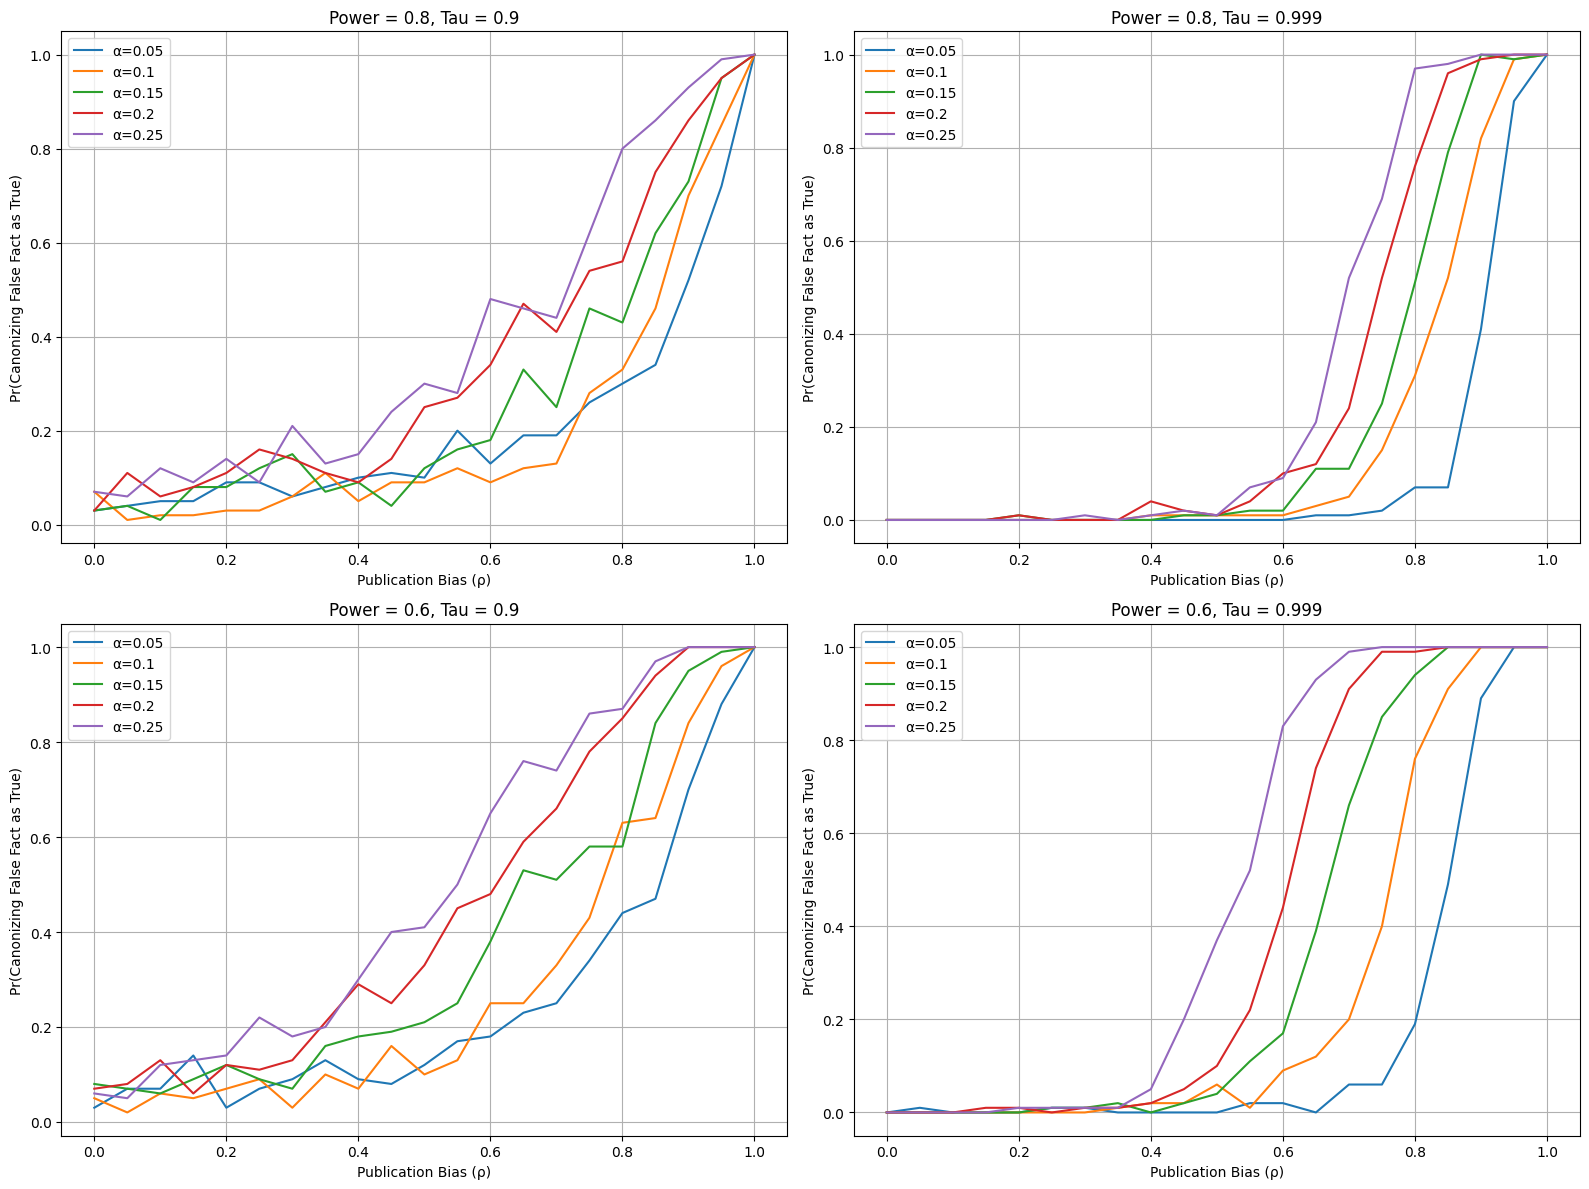

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- シミュレーション関数 ---
def simulate_canonization(pub_bias, alpha, power, tau, true_hypothesis, initial_prior=0.5, max_steps=10000):
    prob_true = initial_prior
    for _ in range(max_steps):
        # Canonization ルール
        if prob_true >= tau:
            return int(not true_hypothesis)  # false hypothesis が canonized as true された場合 → 1
        if prob_true <= (1 - tau):
            return 0  # canonized as false → 0

        rand = np.random.rand()
        if true_hypothesis:
            if rand < power:  # true positive
                prob_true = (power * prob_true) / ((power * prob_true) + (alpha * (1 - prob_true)))
            else:  # false negative
                if np.random.rand() < (1 - pub_bias):  # negative result is published
                    prob_true = ((1 - power) * prob_true) / (((1 - power) * prob_true) + ((1 - alpha) * (1 - prob_true)))
        else:
            if rand < alpha:  # false positive
                prob_true = (power * prob_true) / ((power * prob_true) + (alpha * (1 - prob_true)))
            else:  # true negative
                if np.random.rand() < (1 - pub_bias):  # negative result is published
                    prob_true = ((1 - power) * prob_true) / (((1 - power) * prob_true) + ((1 - alpha) * (1 - prob_true)))
    return 0  # canonization に達しなかった場合 → 0

# --- パラメータ設定 ---
alphas = [0.05, 0.1, 0.15, 0.2, 0.25]
pub_biases = np.linspace(0, 1, 21)
num_runs = 100
powers = [0.8, 0.6]
taus = [0.9, 0.999]

# --- グラフ表示用 2x2 サブプロット ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# タイトル対応表
titles = [
    "Power = 0.8, Tau = 0.9",
    "Power = 0.8, Tau = 0.999",
    "Power = 0.6, Tau = 0.9",
    "Power = 0.6, Tau = 0.999"
]

# --- 各条件に対してシミュレーションを実行してプロット ---
for i, (power, tau) in enumerate([(0.8, 0.9), (0.8, 0.999), (0.6, 0.9), (0.6, 0.999)]):
    ax = axes[i]
    for alpha in alphas:
        canonized_false = []
        for pub_bias in pub_biases:
            false_count = 0
            for _ in range(num_runs):
                result = simulate_canonization(pub_bias, alpha, power, tau, true_hypothesis=False)
                false_count += result
            canonized_false.append(false_count / num_runs)
        ax.plot(pub_biases, canonized_false, label=f'α={alpha}')
    ax.set_title(titles[i])
    ax.set_xlabel('Publication Bias (ρ)')
    ax.set_ylabel('Pr(Canonizing False Fact as True)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


出版バイアスρが強いとture negativeで更新されない <br>
教理化（列聖化; canonization)のしきい値τに到達すると更新をやめる

## 世代間再生産(進化シミュレーション)

検出力・false positive・努力の関係 (図8.6)は省略

### 努力するラボほど新規研究しないという設定↓

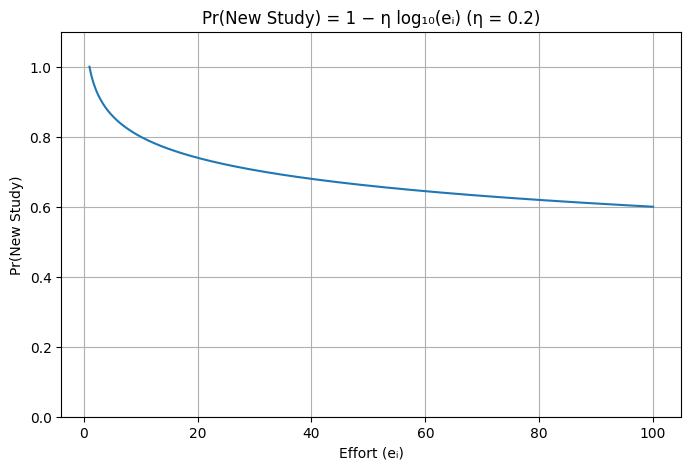

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Effort values from 1 to 100
effort_values = np.linspace(1, 100, 500)
eta = 0.2

# Calculate Pr(new study)
pr_new_study = 1 - eta * np.log10(effort_values)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(effort_values, pr_new_study)
plt.xlabel('Effort (eᵢ)')
plt.ylabel('Pr(New Study)')
plt.title('Pr(New Study) = 1 − η log₁₀(eᵢ) (η = 0.2)')
plt.grid(True)
plt.ylim(0, 1.1)
plt.show()


### 出版バイアス <br>
陽性結果（仮説支持）は常に発表され、報酬は1
<br>
陰性結果（仮説否定）は、確率 𝑝 ≤ 1 でしか発表されず、発表されても報酬は 
𝑣 ≤ 1

### 進化ルール

- ランダムに10のラボを選び、その中で最も古いラボを退場させる（死ぬ）
- 再びランダムに10のラボを選び、今度は最も高い報酬を得ているラボを「繁殖」させる

### 変異
- 新たに作られる“子ラボ”は、親ラボの特徴（検出力と努力）を継承する。
- 検出力（power）と努力（effort）それぞれに、独立した突然変異確率を設定：
- 検出力の突然変異率：𝜇𝑊
- 努力の突然変異率：𝜇𝑒
- 突然変異が起きた場合、その値には平均0、標準偏差𝜎𝑊または𝜎𝑒の正規分布からの値が加えられる。

### 評価則はFDR (False Discovery Rate)
$$
\mathrm{FDR} = \frac{b p (1 - W) + (1 - b) \alpha}{b \left[ W + (1 - W)p \right] + (1 - b) \left[ \alpha + (1 - \alpha)p \right]}
$$
ここで：
<br>
b：仮説が真である確率（base-rate）
<br>
p：陰性結果が出版される確率（prob-publish-neg-result）
<br>
W：平均検出力（mean power）
<br>
α：平均偽陽性率（mean false positive rate）

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

# FDR calculation
def compute_fdr(b, p, W, alpha):
    numerator = b * p * (1 - W) + (1 - b) * alpha
    denominator = b * (W + (1 - W) * p) + (1 - b) * (alpha + (1 - alpha) * p)
    return numerator / denominator if denominator != 0 else 0

# Evolutionary simulation model
def simulate_evolutionary_model(N, b, e0, W0, p, v, mu_e, mu_W, sigma_e, sigma_W, steps=10000):
    efforts = np.full(N, e0)
    powers = np.full(N, W0)
    payoffs = np.zeros(N)
    ages = np.zeros(N)
    
    mean_effort_history = []
    mean_power_history = []
    mean_fpr_history = []
    fdr_history = []

    for t in range(steps):
        # Science stage
        for i in range(N):
            Pr_new_study = 1 - 0.2 * np.log10(efforts[i])
            if np.random.rand() < Pr_new_study:
                truth = np.random.rand() < b
                if truth:
                    if np.random.rand() < powers[i]:
                        payoffs[i] += 1  # true positive
                    else:
                        if np.random.rand() < p:
                            payoffs[i] += v  # false negative, published
                else:
                    fpr = powers[i] / (1 + (1 - powers[i]) * efforts[i])
                    if np.random.rand() < fpr:
                        payoffs[i] += 1  # false positive
                    else:
                        if np.random.rand() < p:
                            payoffs[i] += v  # true negative, published
        
        # Evolution stage
        death_candidates = np.random.choice(N, 10, replace=False)
        oldest = death_candidates[np.argmax(ages[death_candidates])]
        birth_candidates = np.random.choice(N, 10, replace=False)
        fittest = birth_candidates[np.argmax(payoffs[birth_candidates])]

        efforts[oldest] = efforts[fittest]
        powers[oldest] = powers[fittest]
        payoffs[oldest] = 0
        ages[oldest] = 0

        if np.random.rand() < mu_e:
            efforts[oldest] += np.random.normal(0, sigma_e)
            efforts[oldest] = np.clip(efforts[oldest], 1, 100)

        if np.random.rand() < mu_W:
            powers[oldest] += np.random.normal(0, sigma_W)
            powers[oldest] = np.clip(powers[oldest], 0, 1)

        # Age increment
        ages += 1

        # Tracking metrics
        mean_effort = np.mean(efforts)
        mean_power = np.mean(powers)
        mean_fpr = np.mean([powers[i] / (1 + (1 - powers[i]) * efforts[i]) for i in range(N)])
        fdr = compute_fdr(b, p, mean_power, mean_fpr)

        mean_effort_history.append(mean_effort)
        mean_power_history.append(mean_power)
        mean_fpr_history.append(mean_fpr)
        fdr_history.append(fdr)

    return mean_effort_history, mean_power_history, mean_fpr_history, fdr_history

# Plotting function
def plot_simulation(N, b, e0, W0, p, v, mu_e, mu_W, sigma_e, sigma_W):
    effort_hist, power_hist, fpr_hist, fdr_hist = simulate_evolutionary_model(
        N, b, e0, W0, p, v, mu_e, mu_W, sigma_e, sigma_W
    )
    time = np.arange(len(effort_hist))

    # Plot 1: Power, FPR, FDR over time
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(time, power_hist, label='Mean Power')
    plt.plot(time, fpr_hist, label='Mean False Positive Rate')
    plt.plot(time, fdr_hist, label='False Discovery Rate (FDR)')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Evolution of Power, FPR, and FDR')
    plt.legend()
    plt.grid(True)

    # Plot 2: Effort over time
    plt.subplot(1, 2, 2)
    plt.plot(time, effort_hist, label='Mean Effort', color='orange')
    plt.xlabel('Time')
    plt.ylabel('Effort')
    plt.title('Evolution of Effort')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Interactive widget
interact(
    plot_simulation,
    N=IntSlider(min=1, max=100, step=1, value=50, description='N'),
    b=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5, description='(b)'),
    e0=FloatSlider(min=1, max=100, step=1, value=75, description='(e₀)'),
    W0=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.8, description='(W₀)'),
    p=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5, description='(p)'),
    v=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5, description=' (v)'),
    mu_e=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.1, description='Mutation e'),
    mu_W=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.1, description='Mutation W'),
    sigma_e=FloatSlider(min=0.0, max=10.0, step=0.1, value=1.0, description='Mu SD e'),
    sigma_W=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.05, description='Mu SD W')
)


interactive(children=(IntSlider(value=50, description='N', min=1), FloatSlider(value=0.5, description='(b)', m…

<function __main__.plot_simulation(N, b, e0, W0, p, v, mu_e, mu_W, sigma_e, sigma_W)>

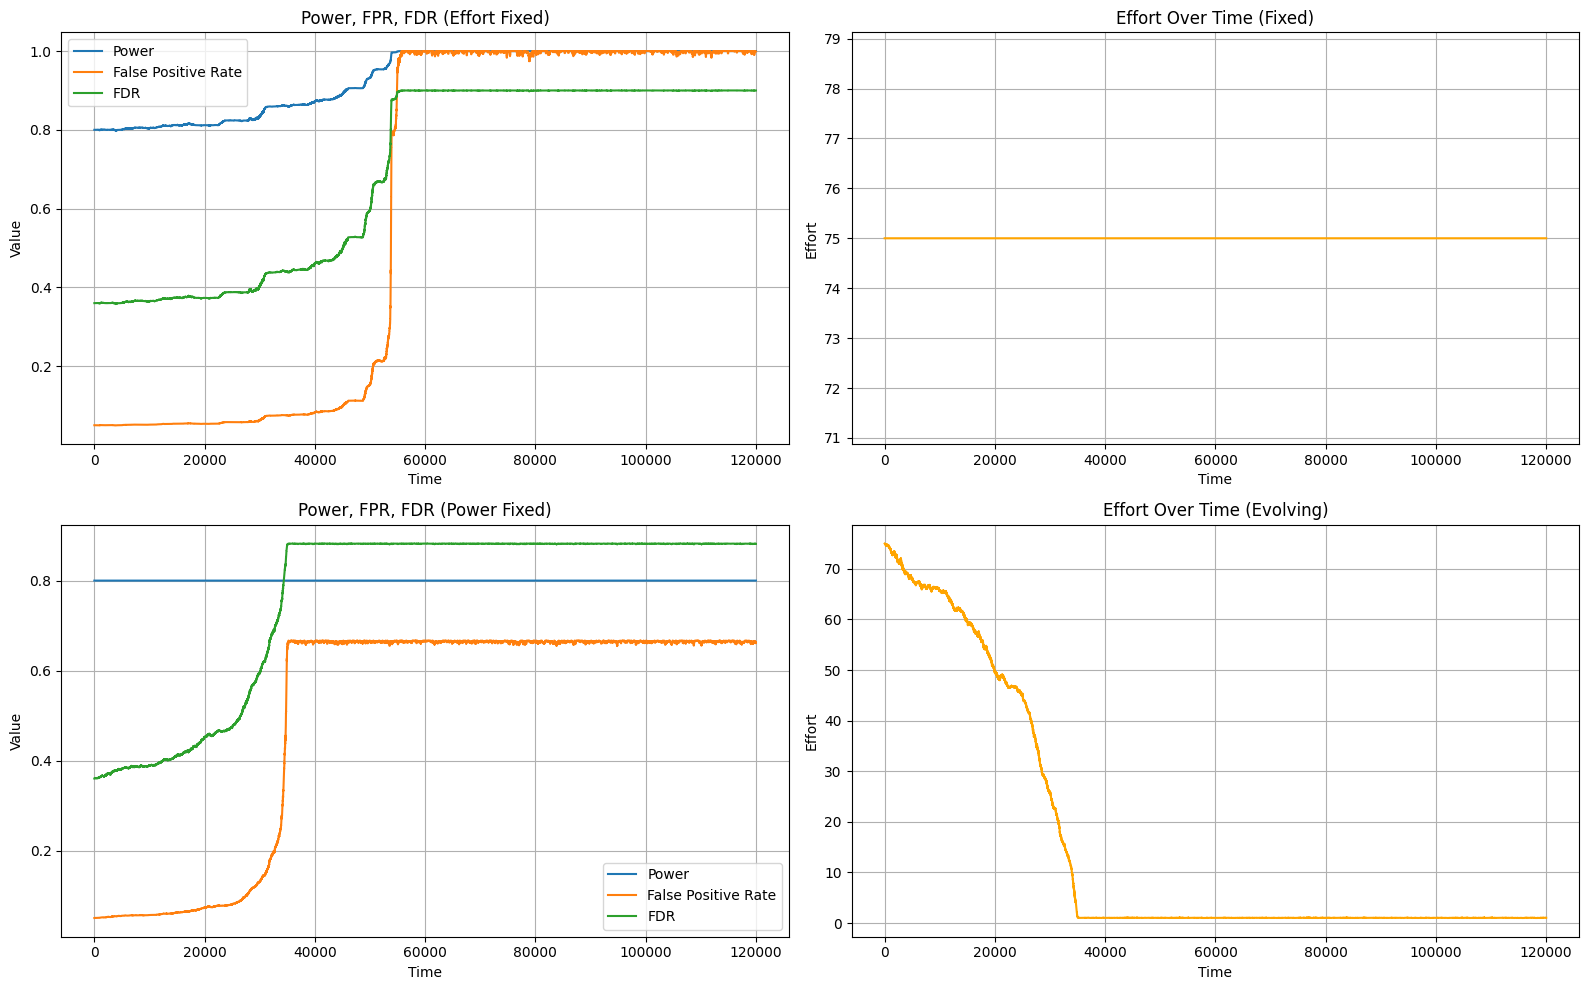

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed parameters
N = 100
b = 0.1
p = 0.0
v = 0.0
mu_e = 0.1
mu_W = 0.01
sigma_e = 1.0
sigma_W = 0.01
steps = 120000

def compute_fdr(b, p, W, alpha):
    numerator = b * p * (1 - W) + (1 - b) * alpha
    denominator = b * (W + (1 - W) * p) + (1 - b) * (alpha + (1 - alpha) * p)
    return numerator / denominator if denominator != 0 else 0

def run_simulation(N, b, e0, W0, p, v, mu_e, mu_W, sigma_e, sigma_W, steps, fix_effort=False, fix_power=False):
    efforts = np.full(N, e0)
    powers = np.full(N, W0)
    payoffs = np.zeros(N)
    ages = np.zeros(N)

    effort_hist, power_hist, fpr_hist, fdr_hist = [], [], [], []

    for _ in range(steps):
        for i in range(N):
            Pr_new_study = 1 - 0.2 * np.log10(efforts[i])
            if np.random.rand() < Pr_new_study:
                truth = np.random.rand() < b
                if truth:
                    if np.random.rand() < powers[i]:
                        payoffs[i] += 1
                    elif np.random.rand() < p:
                        payoffs[i] += v
                else:
                    fpr = powers[i] / (1 + (1 - powers[i]) * efforts[i])
                    if np.random.rand() < fpr:
                        payoffs[i] += 1
                    elif np.random.rand() < p:
                        payoffs[i] += v

        death_candidates = np.random.choice(N, 10, replace=False)
        oldest = death_candidates[np.argmax(ages[death_candidates])]
        birth_candidates = np.random.choice(N, 10, replace=False)
        fittest = birth_candidates[np.argmax(payoffs[birth_candidates])]

        efforts[oldest] = efforts[fittest]
        powers[oldest] = powers[fittest]
        payoffs[oldest] = 0
        ages[oldest] = 0

        if not fix_effort and np.random.rand() < mu_e:
            efforts[oldest] += np.random.normal(0, sigma_e)
            efforts[oldest] = np.clip(efforts[oldest], 1, 100)

        if not fix_power and np.random.rand() < mu_W:
            powers[oldest] += np.random.normal(0, sigma_W)
            powers[oldest] = np.clip(powers[oldest], 0, 1)

        ages += 1

        mean_effort = np.mean(efforts)
        mean_power = np.mean(powers)
        mean_fpr = np.mean([powers[i] / (1 + (1 - powers[i]) * efforts[i]) for i in range(N)])
        fdr = compute_fdr(b, p, mean_power, mean_fpr)

        effort_hist.append(mean_effort)
        power_hist.append(mean_power)
        fpr_hist.append(mean_fpr)
        fdr_hist.append(fdr)

    return effort_hist, power_hist, fpr_hist, fdr_hist

# Simulation 1: fix effort, let power evolve
effort1, power1, fpr1, fdr1 = run_simulation(N, b, e0=75, W0=0.8, p=p, v=v,
                                             mu_e=0.0, mu_W=mu_W,
                                             sigma_e=sigma_e, sigma_W=sigma_W,
                                             steps=steps, fix_effort=True)

# Simulation 2: fix power, let effort evolve
effort2, power2, fpr2, fdr2 = run_simulation(N, b, e0=75, W0=0.8, p=p, v=v,
                                             mu_e=mu_e, mu_W=0.0,
                                             sigma_e=sigma_e, sigma_W=sigma_W,
                                             steps=steps, fix_power=True)

# Plotting
time = np.arange(steps)
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: power, fpr, FDR with fixed effort
axs[0, 0].plot(time, power1, label='Power')
axs[0, 0].plot(time, fpr1, label='False Positive Rate')
axs[0, 0].plot(time, fdr1, label='FDR')
axs[0, 0].set_title('Power, FPR, FDR (Effort Fixed)')
axs[0, 0].set_xlabel('Time')
axs[0, 0].set_ylabel('Value')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Top-right: effort over time (fixed effort)
axs[0, 1].plot(time, effort1, label='Effort', color='orange')
axs[0, 1].set_title('Effort Over Time (Fixed)')
axs[0, 1].set_xlabel('Time')
axs[0, 1].set_ylabel('Effort')
axs[0, 1].grid(True)

# Bottom-left: power, fpr, FDR with fixed power
axs[1, 0].plot(time, power2, label='Power')
axs[1, 0].plot(time, fpr2, label='False Positive Rate')
axs[1, 0].plot(time, fdr2, label='FDR')
axs[1, 0].set_title('Power, FPR, FDR (Power Fixed)')
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Value')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Bottom-right: effort over time (evolving)
axs[1, 1].plot(time, effort2, label='Effort', color='orange')
axs[1, 1].set_title('Effort Over Time (Evolving)')
axs[1, 1].set_xlabel('Time')
axs[1, 1].set_ylabel('Effort')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()
